In [1]:
import glob
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from tqdm import tqdm
from pathlib import Path
from red_gym_env_v2 import RedGymEnv

In [2]:
CHECKPOINTS = sorted(glob.glob("runs/poke_*_steps.zip"))
CHECKPOINTS = CHECKPOINTS[::50]
TEST_STATES = sorted(glob.glob("battle_states/Test/*.state"))

print("Found checkpoints:", len(CHECKPOINTS))
print("Found test states:", len(TEST_STATES))

Found checkpoints: 34
Found test states: 8


In [3]:
from pathlib import Path

EPISODES_PER_STATE = 3

def eval_on_state(model, state_path, debug=False):
    env_config = {
        "headless": True,
        "save_final_state": False,
        "early_stop": True,
        "action_freq": 60,
        "max_steps": 500,  # shorter episodes for eval
        "print_rewards": False,
        "save_video": False,
        "fast_video": False,
        "session_path": Path("battle_runs"),
        "gb_path": "/home/di-lab1/PokemonRedExperiments/PokemonRed.gb",
        "debug": False,
        "init_state": state_path,
    }

    env = RedGymEnv(env_config)

    wins = 0

    for ep in range(EPISODES_PER_STATE):
        obs, info = env.reset()

        done = False
        ep_reward = 0.0
        last_info = {}

        steps = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, last_info = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            steps += 1

        if debug:
            print(f"[DEBUG] state={state_path}, ep={ep}, steps={steps}, reward={ep_reward}")
            print("        final info:", last_info)

        # ---- WIN LOGIC (cascade of fallbacks) ----
        if last_info.get("won", 0) == 1:
            wins += 1
        elif last_info.get("battle_won", 0) == 1:
            wins += 1
        elif last_info.get("terminated_by") == "battle" and ep_reward > 0:
            wins += 1
        elif ep_reward > 0:
            # last resort: positive reward ⇒ treat as win
            wins += 1
        # else: it's a loss/timeout
        # -----------------------------------------

    env.close()
    return wins / EPISODES_PER_STATE


In [4]:
checkpoint_results = {}

for ckpt in tqdm(CHECKPOINTS):
    model = PPO.load(ckpt)
    state_winrates = []

    for state in TEST_STATES:
        wr = eval_on_state(model, state)
        state_winrates.append(wr)

    avg_wr = np.mean(state_winrates)
    checkpoint_results[ckpt] = avg_wr
    print(f"AVG for {ckpt}: {avg_wr:.3f}", end="")

  3%|▎         | 1/34 [01:15<41:28, 75.40s/it]

AVG for runs/poke_100139008_steps.zip: 0.292

  6%|▌         | 2/34 [02:29<39:52, 74.77s/it]

AVG for runs/poke_111935488_steps.zip: 0.375

  9%|▉         | 3/34 [03:39<37:22, 72.33s/it]

...

AVG for runs/poke_72089600_steps.zip: 0.500

 97%|█████████▋| 33/34 [44:02<01:12, 72.91s/it]

AVG for runs/poke_83886080_steps.zip: 0.333

100%|██████████| 34/34 [45:13<00:00, 79.80s/it]

AVG for runs/poke_95682560_steps.zip: 0.333

In [14]:
#sorted_ckpts = sorted(checkpoint_results.items(), key=lambda x: x[1], reverse=True)
unsorted_ckpts = list(checkpoint_results.items())
for ckpt, wr in unsorted_ckpts:
    print(f"{ckpt}: {wr:.3f}")

runs/poke_100139008_steps.zip: 0.292
runs/poke_111935488_steps.zip: 0.375
runs/poke_123731968_steps.zip: 0.375
runs/poke_135528448_steps.zip: 0.417
runs/poke_147324928_steps.zip: 0.375
runs/poke_159121408_steps.zip: 0.333
runs/poke_170917888_steps.zip: 0.292
runs/poke_182976512_steps.zip: 0.333
runs/poke_194510848_steps.zip: 0.375
runs/poke_206569472_steps.zip: 0.250
runs/poke_218103808_steps.zip: 0.333
runs/poke_230162432_steps.zip: 0.250
runs/poke_241696768_steps.zip: 0.292
runs/poke_253755392_steps.zip: 0.125
runs/poke_265027584_steps.zip: 0.250
runs/poke_277086208_steps.zip: 0.292
runs/poke_288620544_steps.zip: 0.250
runs/poke_300679168_steps.zip: 0.292
runs/poke_312475648_steps.zip: 0.375
runs/poke_324272128_steps.zip: 0.375
runs/poke_336068608_steps.zip: 0.292
runs/poke_347865088_steps.zip: 0.375
runs/poke_359661568_steps.zip: 0.250
runs/poke_371458048_steps.zip: 0.167
runs/poke_383254528_steps.zip: 0.458
runs/poke_395051008_steps.zip: 0.333
runs/poke_406847488_steps.zip: 0.292
r

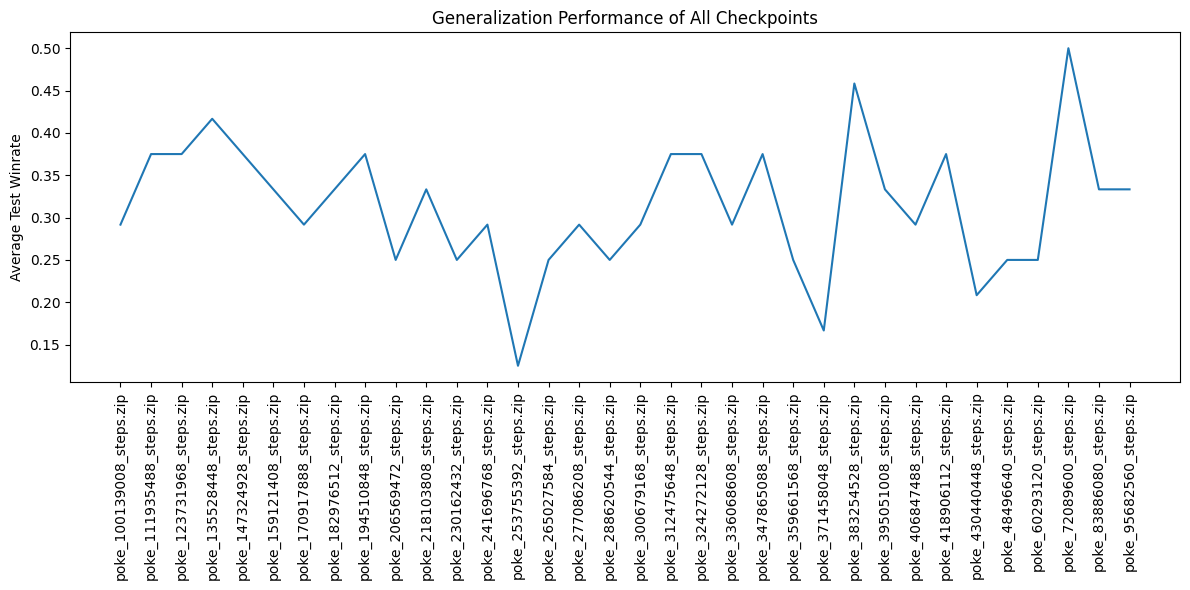

In [16]:
plt.figure(figsize=(12,6))
names = [os.path.basename(k) for k,_ in unsorted_ckpts]
vals = [v for _,v in unsorted_ckpts]

plt.plot(names, vals)
plt.xticks(rotation=90)
plt.ylabel("Average Test Winrate")
plt.title("Generalization Performance of All Checkpoints")
plt.tight_layout()
plt.show()